In [47]:
from datasets import load_dataset
from transformers import AutoTokenizer
import modelscope

dataset = load_dataset("yelp_review_full")
# tokenizer = AutoTokenizer.from_pretrained("google-bert/bert-base-cased")
# from modelscope import snapshot_download
# model_dir = snapshot_download('google-bert/bert-base-cased', local_dir='./model/bert-base-cased/')
tokenizer = AutoTokenizer.from_pretrained("./model/bert-base-cased")



In [ ]:
def tokenize(examples):
    return tokenizer(examples["text"], padding="max_length", truncation=True)

dataset = dataset.map(tokenize, batched=True, )

Map:   0%|          | 0/650000 [00:00<?, ? examples/s]

In [42]:
dataset

DatasetDict({
    train: Dataset({
        features: ['label', 'text'],
        num_rows: 650000
    })
    test: Dataset({
        features: ['label', 'text'],
        num_rows: 50000
    })
})

In [37]:
dataset = load_dataset("yelp_review_full")

In [38]:
dataset

DatasetDict({
    train: Dataset({
        features: ['label', 'text'],
        num_rows: 650000
    })
    test: Dataset({
        features: ['label', 'text'],
        num_rows: 50000
    })
})

In [ ]:
# !pip install -U transformers datasets evaluate accelerate timm

In [17]:
from transformers import AutoModelForSequenceClassification

model = AutoModelForSequenceClassification.from_pretrained("./model/bert-base-cased", num_labels=5)


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at ./model/bert-base-cased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [18]:
import numpy as np
import evaluate

metric = evaluate.load("accuracy")

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    # convert the logits to their predicted class
    predictions = np.argmax(logits, axis=-1)
    return metric.compute(predictions=predictions, references=labels)

In [26]:
from transformers import TrainingArguments

training_args = TrainingArguments(
    output_dir="yelp_review_classifier",
    eval_strategy="epoch",
    per_device_train_batch_size=16,
    push_to_hub=False,
)

In [46]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=dataset["train"],
    eval_dataset=dataset["test"],
    compute_metrics=compute_metrics,
)
trainer.train()

KeyboardInterrupt: 

In [30]:
dataset["test"]
dataset['test'][0]

{'label': 0,
 'text': 'I got \'new\' tires from them and within two weeks got a flat. I took my car to a local mechanic to see if i could get the hole patched, but they said the reason I had a flat was because the previous patch had blown - WAIT, WHAT? I just got the tire and never needed to have it patched? This was supposed to be a new tire. \\nI took the tire over to Flynn\'s and they told me that someone punctured my tire, then tried to patch it. So there are resentful tire slashers? I find that very unlikely. After arguing with the guy and telling him that his logic was far fetched he said he\'d give me a new tire \\"this time\\". \\nI will never go back to Flynn\'s b/c of the way this guy treated me and the simple fact that they gave me a used tire!',
 'input_ids': [101,
  146,
  1400,
  112,
  1207,
  112,
  14337,
  1121,
  1172,
  1105,
  1439,
  1160,
  2277,
  1400,
  170,
  3596,
  119,
  146,
  1261,
  1139,
  1610,
  1106,
  170,
  1469,
  19459,
  1106,
  1267,
  1191,
 

In [17]:
import json
import matplotlib.pyplot as plt
import pandas as pd

In [27]:
log_path = 'G:/model_weights/fine_turning_model/t5/checkpoint-5000/trainer_state.json'

with open(log_path, 'r', encoding='utf-8') as f:
    log = json.load(f)

In [28]:
loss_log = log["log_history"]

In [29]:
df_loss = pd.DataFrame(loss_log)

In [30]:
len(df_loss)

510

In [21]:
df_loss = df_loss.dropna(subset=["loss"])
df_loss.head()

,epoch,grad_norm,learning_rate,loss,step,eval_loss,eval_runtime,eval_samples_per_second,eval_steps_per_second
0,0.003077,0.457459,0.00001,0.0043,10,NaN,NaN,NaN,NaN
1,0.006154,0.173016,0.00001,0.0055,20,NaN,NaN,NaN,NaN
2,0.009231,0.167967,0.00001,0.0038,30,NaN,NaN,NaN,NaN
3,0.012308,0.237235,0.00001,0.0055,40,NaN,NaN,NaN,NaN
4,0.015385,0.122683,0.00001,0.0060,50,NaN,NaN,NaN,NaN


In [25]:
len(df_loss)

500

In [31]:
df_loss = df_loss[df_loss["loss"] < 0.02]
loss = df_loss["loss"].values


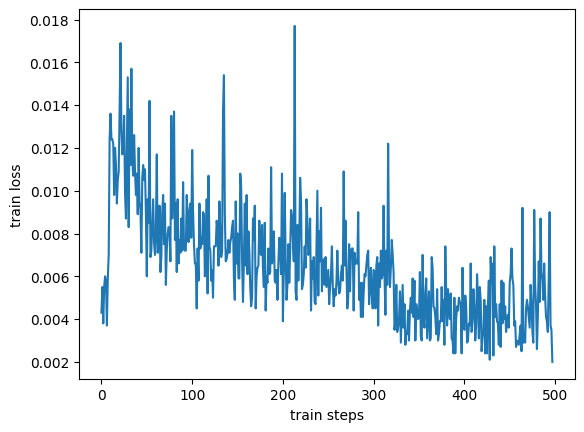

In [33]:
plt.plot(loss)
plt.xlabel('train steps')
plt.ylabel('train loss')
plt.show()

In [2]:
import sacrebleu
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction
import jieba  # 用于中文分词

g:\software\anaconda\envs\pytorch\Lib\site-packages\jieba\_compat.py:18: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


In [4]:
list(jieba.cut('双蛇发球机'))

Building prefix dict from the default dictionary ...
Loading model from cache C:\Users\lkjx0\AppData\Local\Temp\jieba.cache
Loading model cost 0.290 seconds.
Prefix dict has been built successfully.


['双蛇', '发球', '机']

In [5]:
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction
import jieba  # 用于中文分词

# 中文分词函数
def tokenize_chinese(text):
    return list(jieba.cut(text))

# 模型生成结果（hypotheses）
hypotheses = [
    "人工智能是让机器模拟人类智能行为的技术。",
    "人工智能是一种使计算机能够执行通常需要人类智能的任务的技术。",
    "人工智能就是让电脑像人一样思考和学习。",
    "人工智能是指由人制造出来的机器所表现出来的智能。",
    "人工智能技术包括机器学习、深度学习和自然语言处理等。"
]

# 参考答案（每个 hypothesis 对应一个 reference 列表）
references = [
    ["人工智能是让机器具备类似人类智能的能力。"],
    ["人工智能是研究如何让计算机模拟人类智能行为的科学。"],
    ["人工智能旨在使机器能够执行需要人类智能的任务。"],
    ["人工智能是由人类设计的系统所展现出的智能行为。"],
    ["人工智能涵盖机器学习、计算机视觉和自然语言处理等领域。"]
]

# 分词
tokenized_hyps = [tokenize_chinese(hyp) for hyp in hypotheses]
tokenized_refs = [[tokenize_chinese(ref) for ref in ref_list] for ref_list in references]

# 平滑函数（避免零分）
smooth = SmoothingFunction().method4

# 计算每个样本的 BLEU-1 到 BLEU-4
bleu_scores = []
err_num = 0
for hyp, refs in zip(tokenized_hyps, tokenized_refs):
    try:
        bleu1 = sentence_bleu(refs, hyp, weights=(1, 0, 0, 0), smoothing_function=smooth)
        bleu2 = sentence_bleu(refs, hyp, weights=(0.5, 0.5, 0, 0), smoothing_function=smooth)
        bleu3 = sentence_bleu(refs, hyp, weights=(1/3, 1/3, 1/3, 0), smoothing_function=smooth)
        bleu4 = sentence_bleu(refs, hyp, weights=(0.25, 0.25, 0.25, 0.25), smoothing_function=smooth)
    except:
        err_num += 1
        pass
    bleu_scores.append((bleu1, bleu2, bleu3, bleu4))

# 打印每个样本的 BLEU 分数
for i, (b1, b2, b3, b4) in enumerate(bleu_scores):
    print(f"样本 {i+1}: BLEU-1={b1:.4f}, BLEU-2={b2:.4f}, BLEU-3={b3:.4f}, BLEU-4={b4:.4f}")

# 计算平均 BLEU 分数（可选）
avg_bleu1 = sum(s[0] for s in bleu_scores) / len(bleu_scores)
avg_bleu2 = sum(s[1] for s in bleu_scores) / len(bleu_scores)
avg_bleu3 = sum(s[2] for s in bleu_scores) / len(bleu_scores)
avg_bleu4 = sum(s[3] for s in bleu_scores) / len(bleu_scores)
print(f"处理出错的样本数: {err_num}")

print("\n平均 BLEU 分数:")
print(f"BLEU-1: {avg_bleu1:.4f}")
print(f"BLEU-2: {avg_bleu2:.4f}")
print(f"BLEU-3: {avg_bleu3:.4f}")
print(f"BLEU-4: {avg_bleu4:.4f}")

样本 1: BLEU-1=0.7273, BLEU-2=0.5394, BLEU-3=0.4013, BLEU-4=0.2998
样本 2: BLEU-1=0.4375, BLEU-2=0.2415, BLEU-3=0.1049, BLEU-4=0.0592
样本 3: BLEU-1=0.1660, BLEU-2=0.0603, BLEU-3=0.0354, BLEU-4=0.0235
样本 4: BLEU-1=0.5385, BLEU-2=0.2996, BLEU-3=0.1279, BLEU-4=0.0720
样本 5: BLEU-1=0.6923, BLEU-2=0.5371, BLEU-3=0.4285, BLEU-4=0.2978
处理出错的样本数: 0

平均 BLEU 分数:
BLEU-1: 0.5123
BLEU-2: 0.3356
BLEU-3: 0.2196
BLEU-4: 0.1505
